## 1. Загрузка данных

### 1.1. Загрузка данных.

In [2]:
import pandas as pd
data = pd.read_csv('lab3_4.csv')
print(data.head())

   Unnamed: 0  Experience    KPI Status
0           0        18.7  10.22   Fire
1           1        12.0  15.11   Fire
2           2        10.5  21.74   Fire
3           3         8.1  10.70   Fire
4           4        23.5  18.74   Fire


Закодируем столбец Status с помощью LabelEncoder.

In [3]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
data['Status'] = label_encoder.fit_transform(data['Status'])

print(data.head())

   Unnamed: 0  Experience    KPI  Status
0           0        18.7  10.22       0
1           1        12.0  15.11       0
2           2        10.5  21.74       0
3           3         8.1  10.70       0
4           4        23.5  18.74       0


### 1.2. Визуализация данных при помощи диаграммы рассеяния с выделением различных классов ней.

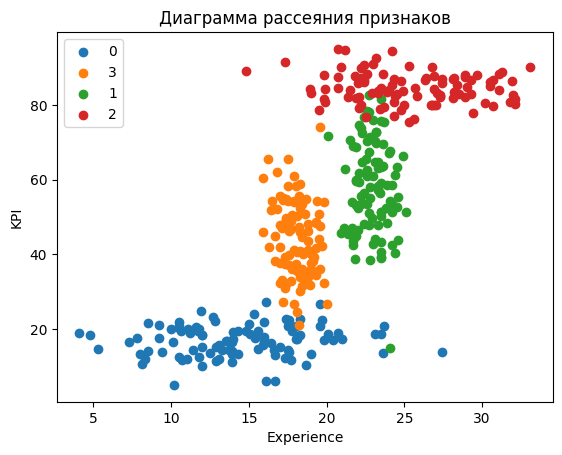

In [4]:
import matplotlib.pyplot as plt

classes = data['Status'].unique()

for status in classes:
    subset = data[data['Status'] == status]
    plt.scatter(subset['Experience'], subset['KPI'], label=status)

plt.xlabel('Experience')
plt.ylabel('KPI')
plt.title('Диаграмма рассеяния признаков')
plt.legend()
plt.show()

### 1.3. Оценка сбалансированность классов.

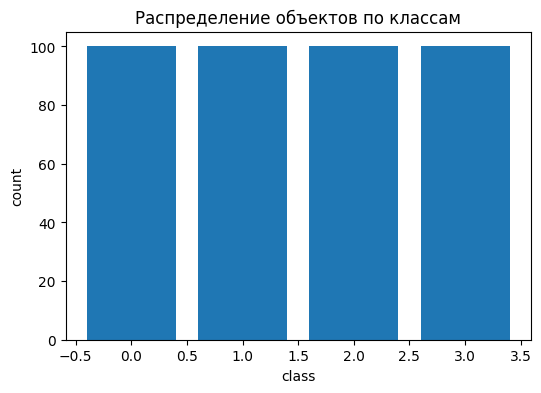

In [5]:
class_counts = data['Status'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(class_counts.index, class_counts.values)
plt.xlabel('class')
plt.ylabel('count')
plt.title('Распределение объектов по классам')
plt.show()

### 1.4. Предобработка данных.

Проверим количество данных и их значения через метод describe().

In [6]:
print(data.describe())

       Unnamed: 0  Experience         KPI      Status
count  400.000000  400.000000  400.000000  400.000000
mean   199.500000   20.161000   50.955350    1.500000
std    115.614301    5.185161   25.834645    1.119434
min      0.000000    4.100000    5.000000    0.000000
25%     99.750000   17.400000   24.762500    0.750000
50%    199.500000   20.050000   50.960000    1.500000
75%    299.250000   23.500000   77.887500    2.250000
max    399.000000   33.100000   95.000000    3.000000


Данные не содержат пропусков и некорректных значений. Но признаки Experience и KPI имеют разный масштаб изменения - поэтому для корректности стандартизируем их. Для выбора наиболее подходящего метод масштабирования нужно проверить выбросы данных через boxplot.

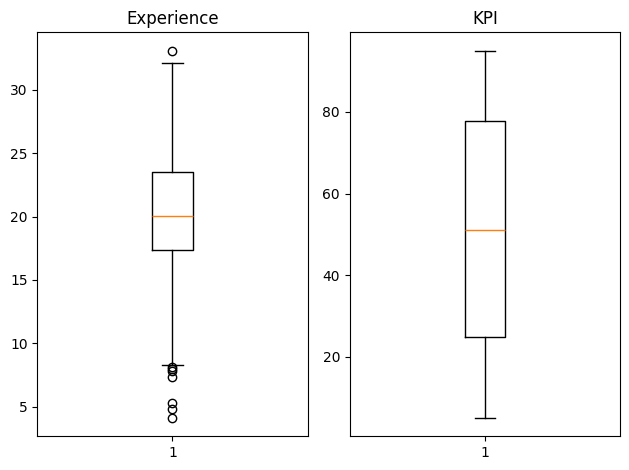

In [7]:
plt.subplot(1,2,1)
plt.boxplot(data['Experience'])
plt.title('Experience')

plt.subplot(1,2,2)
plt.boxplot(data['KPI'])
plt.title('KPI')

plt.tight_layout()
plt.show()

In [8]:
from sklearn.preprocessing import RobustScaler

rb_scaler = RobustScaler()
X = data[['Experience','KPI']]
X_scaled = rb_scaler.fit_transform(X)

print(X_scaled[:5])

[[-0.22131148 -0.76687059]
 [-1.31967213 -0.67482353]
 [-1.56557377 -0.55002353]
 [-1.95901639 -0.75783529]
 [ 0.56557377 -0.60649412]]


### 1.5. Разделение выборки на обучающую и тестовую. 

In [73]:
from sklearn.model_selection import train_test_split
import numpy as np

y = data['Status']
X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=41,stratify=y)
print(X.shape, X_train_scaled.shape, X_test_scaled.shape)

(400, 2) (320, 2) (80, 2)


## 2. kNN

### 2.1. Классификация методом k ближайших соседей с подбором параметров (количество соседей, необходимость взвешивания).

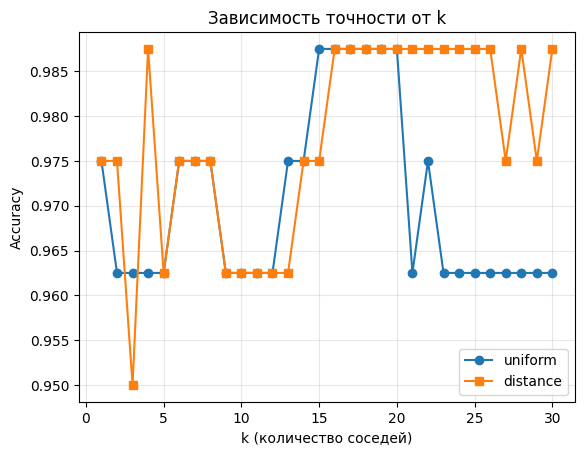

uniform: k=15, Accuracy=0.9875
distance: k=4, Accuracy=0.9875


In [74]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_range = range(1, 31)
acc_uniform = []
acc_distance = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, weights='uniform')
    knn.fit(X_train_scaled, y_train)
    acc_uniform.append(accuracy_score(y_test, knn.predict(X_test_scaled)))
    
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn.fit(X_train_scaled, y_train)
    acc_distance.append(accuracy_score(y_test, knn.predict(X_test_scaled)))

plt.plot(k_range, acc_uniform, marker='o', label='uniform')
plt.plot(k_range, acc_distance, marker='s', label='distance')
plt.xlabel('k (количество соседей)')
plt.ylabel('Accuracy')
plt.title('Зависимость точности от k')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"uniform: k={np.argmax(acc_uniform)+1}, Accuracy={max(acc_uniform):.4f}")
print(f"distance: k={np.argmax(acc_distance)+1}, Accuracy={max(acc_distance):.4f}")

### 2.2. Построение изображения с границами принятия решения.

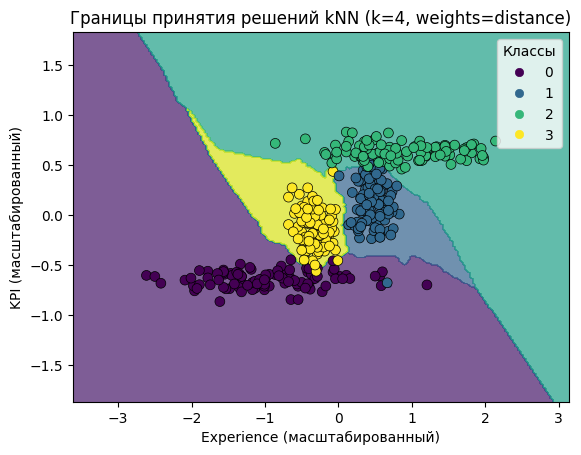

In [11]:
from sklearn.inspection import DecisionBoundaryDisplay

knn_best = KNeighborsClassifier(n_neighbors=4, weights='distance')
knn_best.fit(X_train_scaled, y_train)

display = DecisionBoundaryDisplay.from_estimator(
    knn_best, 
    X_scaled,
    response_method='predict',
    xlabel='Experience (масштабированный)', 
    ylabel='KPI (масштабированный)',
    grid_resolution=200,  
    alpha=0.7,
    cmap='viridis'
)

scatter = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='viridis', edgecolors='k', s=50, linewidth=0.5)
plt.legend(*scatter.legend_elements(), title="Классы", loc='upper right')
plt.title('Границы принятия решений kNN (k=4, weights=distance)')
plt.grid(False)

plt.show()

### 2.3. Построение таблицы ошибок для полученных результатов. Выводы о классификации на основе таблицы ошибок.

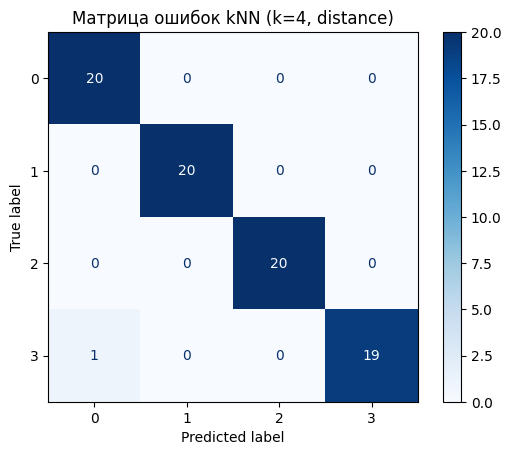

In [75]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    knn_best, 
    X_test_scaled, 
    y_test,
    display_labels=['0', '1', '2', '3'],
    cmap='Blues',
    values_format='d' 
)
plt.title('Матрица ошибок kNN (k=4, distance)')
plt.grid(False)
plt.show()


### 2.4. Рассчит значений Precision, Recall, F1для полученных результатов. Сопоставление с таблицей ошибок.

In [76]:
from sklearn.metrics import precision_recall_fscore_support

y_pred_knn = knn_best.predict(X_test_scaled)

precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred_knn, average=None)
for i in range(4):
    print(f"Класс {i}: Precision={precision[i]:.6f}, Recall={recall[i]:.6f}, F1={f1[i]:.6f}")

print(f"\nСреднее (macro): Precision={precision.mean():.6f}, Recall={recall.mean():.6f}, F1={f1.mean():.6f}")

Класс 0: Precision=0.952381, Recall=1.000000, F1=0.975610
Класс 1: Precision=1.000000, Recall=1.000000, F1=1.000000
Класс 2: Precision=1.000000, Recall=1.000000, F1=1.000000
Класс 3: Precision=1.000000, Recall=0.950000, F1=0.974359

Среднее (macro): Precision=0.988095, Recall=0.987500, F1=0.987492


### 2.5. Построение изображения ROC-кривой, расчет значения AUC для полученных результатов. Вывод о классификации.

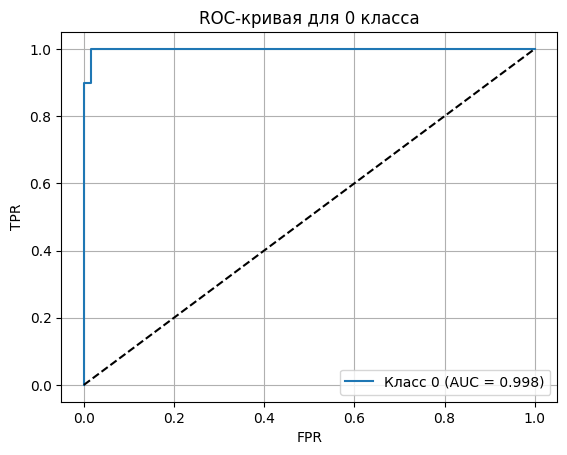

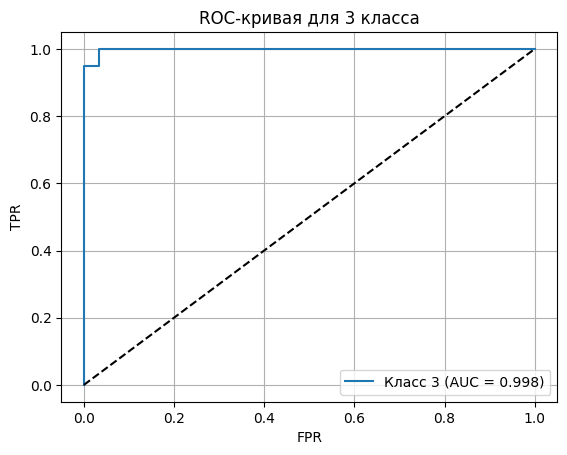

AUC для класса 0: 0.9983
AUC для класса 1: 1.0000
AUC для класса 2: 1.0000
AUC для класса 3: 0.9983

Среднее AUC (macro): 0.9992


In [79]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0,1,2,3])
n_classes = y_test_bin.shape[1]

y_score_knn = knn_best.predict_proba(X_test_scaled)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score_knn[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

index_classes = [0, 3]

for ind_class in index_classes:
    plt.plot(fpr[ind_class], tpr[ind_class], label=f'Класс {ind_class} (AUC = {roc_auc[ind_class]:.3f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.title(f'ROC-кривая для {ind_class} класса')
    plt.legend()
    plt.grid()
    plt.show()

for i in range(n_classes):
    print(f"AUC для класса {i}: {roc_auc[i]:.4f}")

mean_auc = np.mean([roc_auc[i] for i in range(n_classes)])
print(f"\nСреднее AUC (macro): {mean_auc:.4f}")

## 3. Логистическая регрессия

### 3.1. Классификация методом логистической регрессии при различных параметрах (без регуляризации, с l1 регуляризацией, c l2 регуляризацией). Построение диаграммы зависимости точности от наличия регуляризации.

Без регуляризации: Accuracy = 0.9625
L1 регуляризация: Accuracy = 0.9250
L2 регуляризация: Accuracy = 0.8375


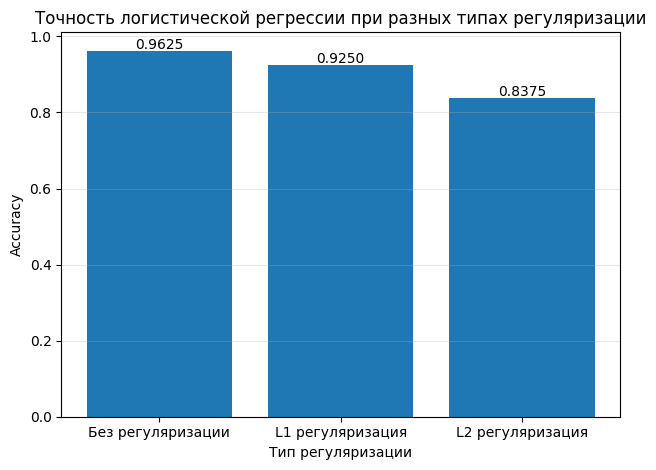

In [15]:
from sklearn.linear_model import LogisticRegression

logistical_regression_models = {
    'Без регуляризации': LogisticRegression(penalty=None, random_state=42, max_iter=1000),
    'L1 регуляризация': LogisticRegression(penalty='l1', solver='liblinear', random_state=42, max_iter=1000),
    'L2 регуляризация': LogisticRegression(penalty='l2', solver='liblinear', random_state=42, max_iter=1000)
}

accuracies = {}
for name, model in logistical_regression_models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    accuracies[name] = acc
    print(f"{name}: Accuracy = {acc:.4f}")

plt.bar(accuracies.keys(), accuracies.values())
plt.xlabel('Тип регуляризации')
plt.ylabel('Accuracy')
plt.title('Точность логистической регрессии при разных типах регуляризации')
for i, (name, acc) in enumerate(accuracies.items()):
    plt.text(i, acc + 0.005, f'{acc:.4f}', ha='center')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 3.2. Построение изображения с границами принятия решения.

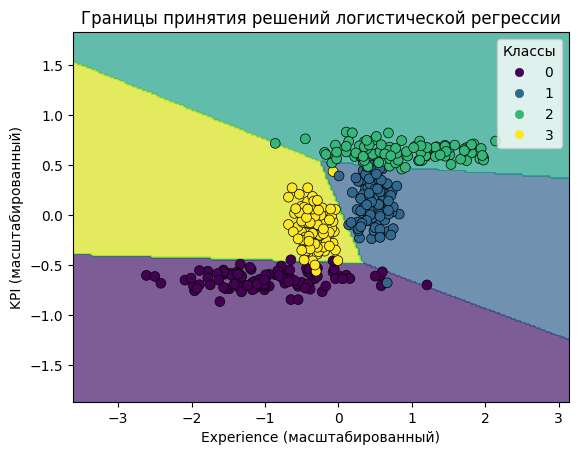

In [16]:
log_reg_best = LogisticRegression(penalty=None, random_state=42, max_iter=1000)
log_reg_best.fit(X_train_scaled, y_train)

display = DecisionBoundaryDisplay.from_estimator(
    log_reg_best, 
    X_scaled,
    response_method='predict',
    xlabel='Experience (масштабированный)', 
    ylabel='KPI (масштабированный)',
    grid_resolution=200,  
    alpha=0.7,
    cmap='viridis'
)

scatter = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='viridis', edgecolors='k', s=50, linewidth=0.5)
plt.legend(*scatter.legend_elements(), title="Классы", loc='upper right')
plt.title('Границы принятия решений логистической регрессии')
plt.grid(False)
plt.show()

### 3.3. Построение таблицы ошибок для полученных результатов. Выводы о классификации на основе таблицы ошибок.

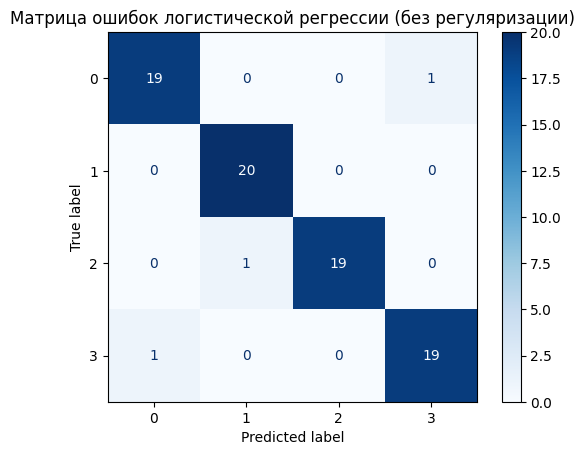

In [ ]:
y_pred_log_reg = log_reg_best.predict(X_test_scaled)

ConfusionMatrixDisplay.from_estimator(
    log_reg_best, 
    X_test_scaled, 
    y_test,
    display_labels=['0', '1', '2', '3'],
    cmap='Blues',
    values_format='d' 
)
plt.title('Матрица ошибок логистической регрессии (без регуляризации)')
plt.grid(False)
plt.show()


### 3.4. Рассчет значений Precision, Recall, F1для полученных результатов. Сопоставление с таблицей ошибок.

In [ ]:
y_pred_log_reg = log_reg_best.predict(X_test_scaled)

precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred_log_reg, average=None)
for i in range(4):
    print(f"Класс {i}: Precision={precision[i]:.6f}, Recall={recall[i]:.6f}, F1={f1[i]:.6f}")

print(f"\nСреднее (macro): Precision={precision.mean():.6f}, Recall={recall.mean():.6f}, F1={f1.mean():.6f}")

Класс 0: Precision=0.950000, Recall=0.950000, F1=0.950000
Класс 1: Precision=0.952381, Recall=1.000000, F1=0.975610
Класс 2: Precision=1.000000, Recall=0.950000, F1=0.974359
Класс 3: Precision=0.950000, Recall=0.950000, F1=0.950000

Среднее (macro): Precision=0.963095, Recall=0.962500, F1=0.962492


### 3.5. Построение изображения ROC-кривой, расчет значения AUC для полученных результатов. Вывод о классификации.

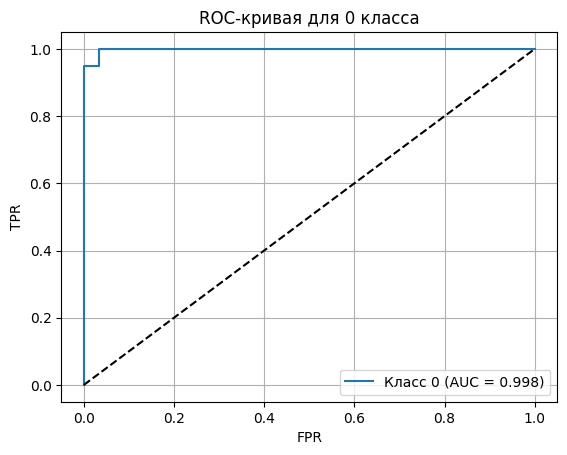

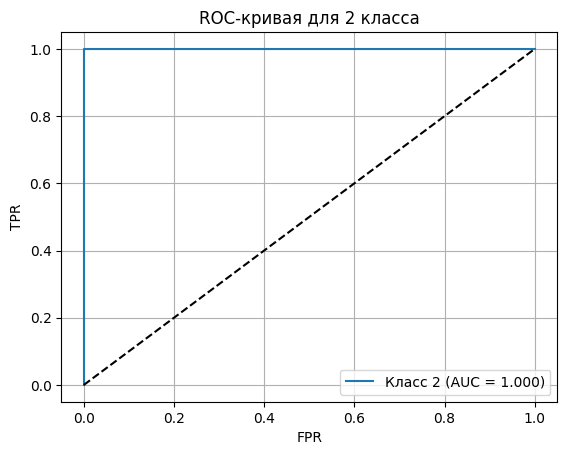

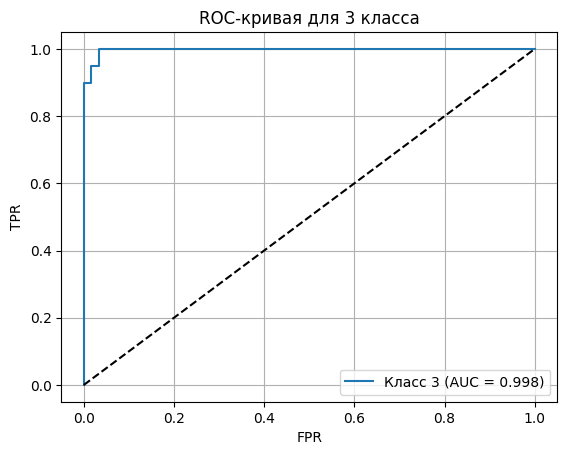

AUC для класса 0: 0.9983
AUC для класса 1: 1.0000
AUC для класса 2: 1.0000
AUC для класса 3: 0.9975

Среднее AUC (macro): 0.9990


In [81]:
y_score_log_reg = log_reg_best.predict_proba(X_test_scaled)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score_log_reg[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score_log_reg.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
roc_auc["macro"] = np.mean([roc_auc[i] for i in range(n_classes)])

ind_classes = [0, 2, 3]

for ind_class in ind_classes:
    plt.plot(fpr[ind_class], tpr[ind_class], label=f'Класс {ind_class} (AUC = {roc_auc[ind_class]:.3f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.title(f'ROC-кривая для {ind_class} класса')
    plt.legend()
    plt.grid()
    plt.show()

for i in range(n_classes):
    print(f"AUC для класса {i}: {roc_auc[i]:.4f}")

mean_auc = np.mean([roc_auc[i] for i in range(n_classes)])
print(f"\nСреднее AUC (macro): {mean_auc:.4f}")

### 4. Метод опорных векторов

### 4.1. Классификация методом опорных векторов при различных параметрах (linear, poly (нужно выбрать степень), rbf). Построение диаграммы зависимости точности от вида ядра.

In [25]:
from sklearn.svm import SVC

poly_accuracies = []

for i in range (2, 10):
    model = SVC(kernel='poly', degree=i, probability=True)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    poly_accuracies.append(acc)
    print(f"degree={i}: Accuracy = {acc:.4f}")

degree=2: Accuracy = 0.7000
degree=3: Accuracy = 0.8750
degree=4: Accuracy = 0.5250
degree=5: Accuracy = 0.8000
degree=6: Accuracy = 0.4625
degree=7: Accuracy = 0.6375
degree=8: Accuracy = 0.4125
degree=9: Accuracy = 0.5875


linear: Accuracy = 0.9625
poly: Accuracy = 0.8750
rbf: Accuracy = 0.9750


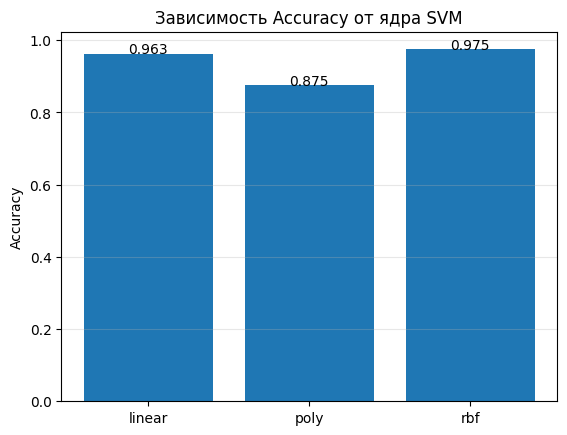

In [ ]:
kernels = ['linear', 'poly', 'rbf']
accuracies = []

for kernel in kernels:
    if kernel == 'poly':
        model = SVC(kernel=kernel, degree=3, probability=True)
    else:
        model = SVC(kernel=kernel, probability=True)
    
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"{kernel}: Accuracy = {acc:.4f}")

plt.bar(kernels, accuracies)
plt.ylabel('Accuracy')
plt.title('Зависимость Accuracy от ядра SVM')
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.001, f"{v:.3f}", ha='center')
plt.grid(axis='y', alpha=0.3)
plt.show()

### 4.2. Построение изображения с границами принятия решения.

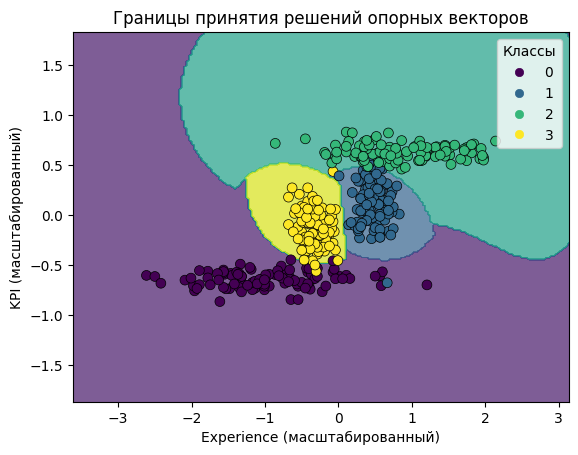

In [28]:
svc_best = SVC(kernel='rbf', probability=True)
svc_best.fit(X_train_scaled, y_train)

display = DecisionBoundaryDisplay.from_estimator(
    svc_best, 
    X_scaled,
    response_method='predict',
    xlabel='Experience (масштабированный)', 
    ylabel='KPI (масштабированный)',
    grid_resolution=200,  
    alpha=0.7,
    cmap='viridis'
)

scatter = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='viridis', edgecolors='k', s=50, linewidth=0.5)
plt.legend(*scatter.legend_elements(), title="Классы", loc='upper right')
plt.title('Границы принятия решений опорных векторов')
plt.grid(False)
plt.show()

### 4.3. Построение таблицы ошибок для полученных результатов. Выводы о классификации на основе таблицы ошибок.

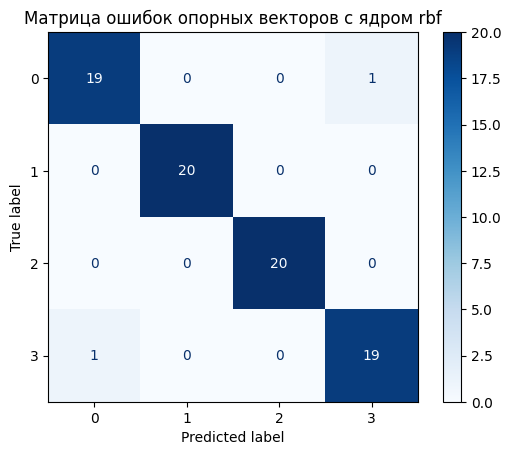

In [34]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred_svc = svc_best.predict(X_test_scaled)

ConfusionMatrixDisplay.from_estimator(
    svc_best, 
    X_test_scaled, 
    y_test,
    display_labels=['0', '1', '2', '3'],
    cmap='Blues',
    values_format='d' 
)
plt.title('Матрица ошибок опорных векторов с ядром rbf')
plt.grid(False)
plt.show()

### 4.4. Рассчет значений Precision, Recall, F1 для полученных результатов. Сопоставление с таблицей ошибок.

In [66]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred_svc, average=None)
for i in range(4):
    print(f"Класс {i}: Precision={precision[i]:.6f}, Recall={recall[i]:.6f}, F1={f1[i]:.6f}")
    
print(f"\nСреднее (macro): Precision={precision.mean():.6f}, Recall={recall.mean():.6f}, F1={f1.mean():.6f}")

Класс 0: Precision=0.950000, Recall=0.950000, F1=0.950000
Класс 1: Precision=1.000000, Recall=1.000000, F1=1.000000
Класс 2: Precision=1.000000, Recall=1.000000, F1=1.000000
Класс 3: Precision=0.950000, Recall=0.950000, F1=0.950000

Среднее (macro): Precision=0.975000, Recall=0.975000, F1=0.975000


### 4.5. Построение изображения ROC-кривой, расчет значения AUC для полученных результатов. Вывод о классификации.

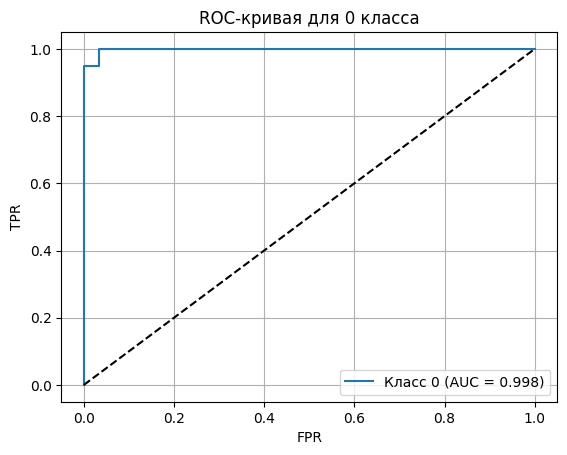

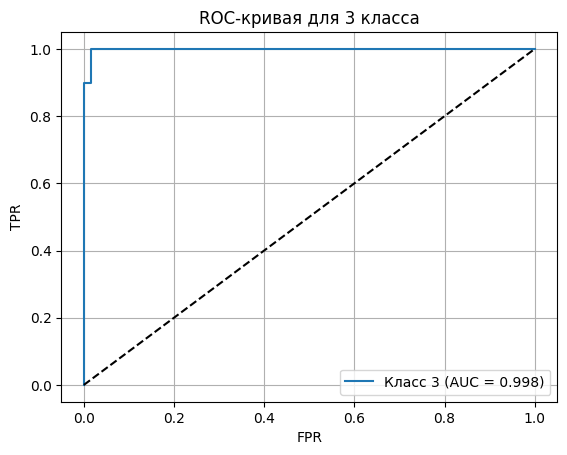

AUC для класса 0: 0.9983
AUC для класса 1: 1.0000
AUC для класса 2: 1.0000
AUC для класса 3: 0.9983

Среднее AUC (macro): 0.9992


In [84]:
y_score_svc = svc_best.predict_proba(X_test_scaled)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score_svc[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score_svc.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
roc_auc["macro"] = np.mean([roc_auc[i] for i in range(n_classes)])

ind_classes = [0, 3]

for ind_class in ind_classes:
    plt.plot(fpr[ind_class], tpr[ind_class], label=f'Класс {ind_class} (AUC = {roc_auc[ind_class]:.3f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.title(f'ROC-кривая для {ind_class} класса')
    plt.legend()
    plt.grid()
    plt.show()

for i in range(n_classes):
    print(f"AUC для класса {i}: {roc_auc[i]:.4f}")
mean_auc = np.mean([roc_auc[i] for i in range(n_classes)])
print(f"\nСреднее AUC (macro): {mean_auc:.4f}")

### 5.Решающие деревья

### 5.1. Классификация методом решающих деревьев при различных параметрах (максимальная глубина/максимальное количество листьев/метрика загрязнения). Построение диаграммы зависимости точности от разных параметров.

Подбор max_depth:

max_depth=1: Accuracy = 0.5000
max_depth=2: Accuracy = 0.7125
max_depth=3: Accuracy = 0.9500
max_depth=4: Accuracy = 0.9750
max_depth=5: Accuracy = 0.9625
max_depth=6: Accuracy = 0.9625
max_depth=7: Accuracy = 0.9625
max_depth=8: Accuracy = 0.9625
max_depth=9: Accuracy = 0.9625
max_depth=10: Accuracy = 0.9625
max_depth=11: Accuracy = 0.9625
max_depth=12: Accuracy = 0.9625
max_depth=13: Accuracy = 0.9625
max_depth=14: Accuracy = 0.9625
max_depth=15: Accuracy = 0.9625
max_depth=16: Accuracy = 0.9625
max_depth=17: Accuracy = 0.9625
max_depth=18: Accuracy = 0.9625
max_depth=19: Accuracy = 0.9625
max_depth=20: Accuracy = 0.9625

Лучшая глубина: max_depth=4, Accuracy=0.9750


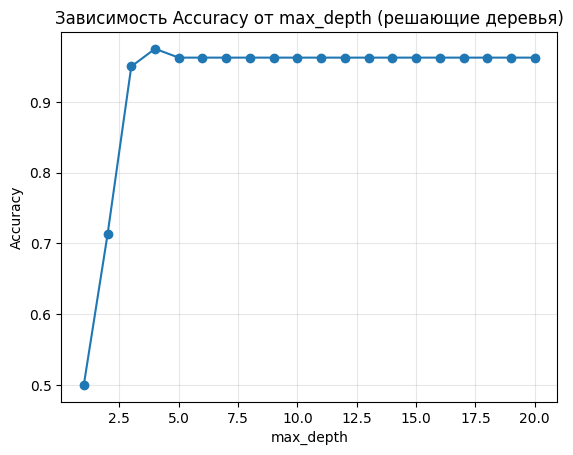

In [42]:
from sklearn.tree import DecisionTreeClassifier

depths = range(1, 21)
depth_accuracies = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    depth_accuracies.append(acc)
    print(f"max_depth={d}: Accuracy = {acc:.4f}")

best_depth = depths[depth_accuracies.index(max(depth_accuracies))]
print(f"\nЛучшая глубина: max_depth={best_depth}, Accuracy={max(depth_accuracies):.4f}")

plt.plot(depths, depth_accuracies, marker='o')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Зависимость Accuracy от max_depth (решающие деревья)')
plt.grid(alpha=0.3)
plt.show()

Подберем max_leaf_nodes:

max_leaf_nodes=2: Accuracy = 0.5000
max_leaf_nodes=3: Accuracy = 0.7125
max_leaf_nodes=4: Accuracy = 0.9375
max_leaf_nodes=5: Accuracy = 0.9500
max_leaf_nodes=6: Accuracy = 0.9625
max_leaf_nodes=7: Accuracy = 0.9625
max_leaf_nodes=8: Accuracy = 0.9625
max_leaf_nodes=9: Accuracy = 0.9625
max_leaf_nodes=10: Accuracy = 0.9625
max_leaf_nodes=11: Accuracy = 0.9750
max_leaf_nodes=12: Accuracy = 0.9750
max_leaf_nodes=13: Accuracy = 0.9750
max_leaf_nodes=14: Accuracy = 0.9750
max_leaf_nodes=15: Accuracy = 0.9750
max_leaf_nodes=16: Accuracy = 0.9750
max_leaf_nodes=17: Accuracy = 0.9750
max_leaf_nodes=18: Accuracy = 0.9750
max_leaf_nodes=19: Accuracy = 0.9750
max_leaf_nodes=20: Accuracy = 0.9750

Лучшее количество листьев: max_leaf_nodes=11, Accuracy=0.9750


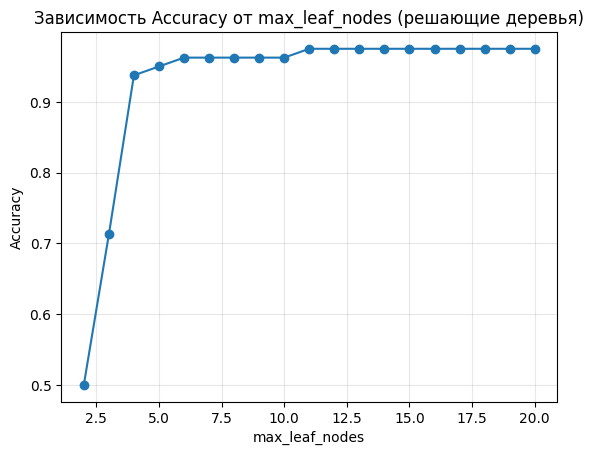

In [45]:
leaf_nodes = range(2, 21)
leaf_accuracies = []

for n in leaf_nodes:
    model = DecisionTreeClassifier(max_depth=best_depth, max_leaf_nodes=n, random_state=42)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    leaf_accuracies.append(acc)
    print(f"max_leaf_nodes={n}: Accuracy = {acc:.4f}")

best_leaf_nodes = leaf_nodes[leaf_accuracies.index(max(leaf_accuracies))]
print(f"\nЛучшее количество листьев: max_leaf_nodes={best_leaf_nodes}, Accuracy={max(leaf_accuracies):.4f}")

plt.plot(leaf_nodes, leaf_accuracies, marker='o')
plt.xlabel('max_leaf_nodes')
plt.ylabel('Accuracy')
plt.title('Зависимость Accuracy от max_leaf_nodes (решающие деревья)')
plt.grid(alpha=0.3)
plt.show()

Подберем criterion:

gini: Accuracy = 0.9750
entropy: Accuracy = 0.9625
log_loss: Accuracy = 0.9625

Лучший критерий: gini, Accuracy=0.9750


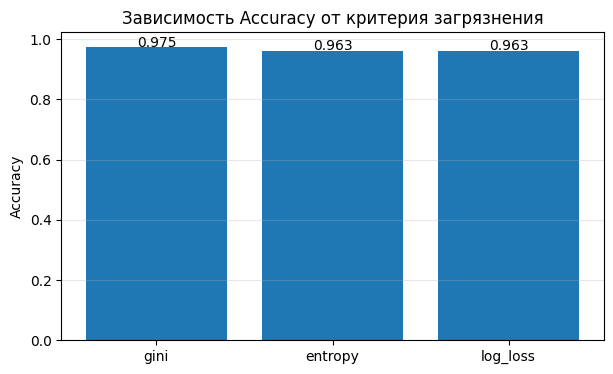

In [ ]:
criteria = ['gini', 'entropy', 'log_loss']
criterion_accuracies = []

for c in criteria:
    model = DecisionTreeClassifier(
        criterion=c,
        max_depth=best_depth,
        max_leaf_nodes=best_leaf_nodes,
        random_state=42
    )
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    criterion_accuracies.append(acc)
    print(f"{c}: Accuracy = {acc:.4f}")

best_criterion = criteria[criterion_accuracies.index(max(criterion_accuracies))]
print(f"\nЛучший критерий: {best_criterion}, Accuracy={max(criterion_accuracies):.4f}")

plt.bar(criteria, criterion_accuracies)
plt.ylabel('Accuracy')
plt.title('Зависимость Accuracy от критерия загрязнения')
for i, v in enumerate(criterion_accuracies):
    plt.text(i, v + 0.001, f"{v:.3f}", ha='center')
plt.grid(axis='y', alpha=0.3)
plt.show()

Модель решающих деревьев.

In [56]:
decision_three_best = DecisionTreeClassifier(
    criterion=best_criterion,
    max_depth=best_depth,
    max_leaf_nodes=best_leaf_nodes,
    random_state=42
)
decision_three_best.fit(X_train_scaled, y_train)
y_pred_decision_three = decision_three_best.predict(X_test_scaled)
best_acc = accuracy_score(y_test, y_pred_decision_three)

print(f"Accuracy = {best_acc:.4f}")

Accuracy = 0.9750


### 5.2. Построение изображения с границами принятия решения.

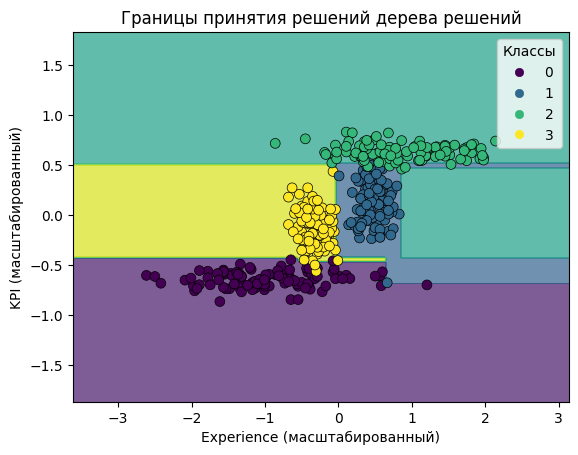

In [57]:
display = DecisionBoundaryDisplay.from_estimator(
    decision_three_best, 
    X_scaled,
    response_method='predict',
    xlabel='Experience (масштабированный)', 
    ylabel='KPI (масштабированный)',
    grid_resolution=200,
    alpha=0.7,
    cmap='viridis'
)

scatter = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='viridis', edgecolors='k', s=50, linewidth=0.5)
plt.legend(*scatter.legend_elements(), title="Классы", loc='upper right')
plt.title('Границы принятия решений дерева решений')
plt.grid(False)
plt.show()

### 5.3. Построение таблицы ошибок для полученных результатов. Выводы о классификации на основе таблицы ошибок.

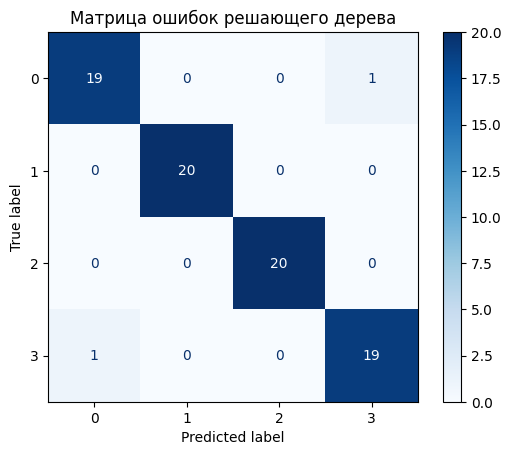

In [58]:
ConfusionMatrixDisplay.from_estimator(
    decision_three_best, 
    X_test_scaled, 
    y_test,
    display_labels=['0', '1', '2', '3'],
    cmap='Blues',
    values_format='d' 
)
plt.title('Матрица ошибок решающего дерева')
plt.grid(False)
plt.show()

### 5.4. Рассчет значений Precision, Recall, F1 для полученных результатов. Сопоставление с таблицей ошибок.

In [63]:
precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred_decision_three, average=None)
for i in range(4):
    print(f"Класс {i}: Precision={precision[i]:.6f}, Recall={recall[i]:.6f}, F1={f1[i]:.6f}")

print(f"\nСреднее (macro): Precision={precision.mean():.6f}, Recall={recall.mean():.6f}, F1={f1.mean():.6f}")

Класс 0: Precision=0.950000, Recall=0.950000, F1=0.950000
Класс 1: Precision=1.000000, Recall=1.000000, F1=1.000000
Класс 2: Precision=1.000000, Recall=1.000000, F1=1.000000
Класс 3: Precision=0.950000, Recall=0.950000, F1=0.950000

Среднее (macro): Precision=0.975000, Recall=0.975000, F1=0.975000


### 5.5. Построение изображения ROC-кривой, расчет значения AUC для полученных результатов. Вывод о классификации.

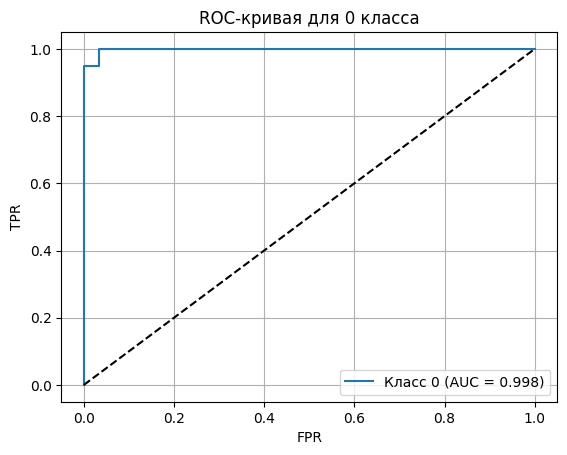

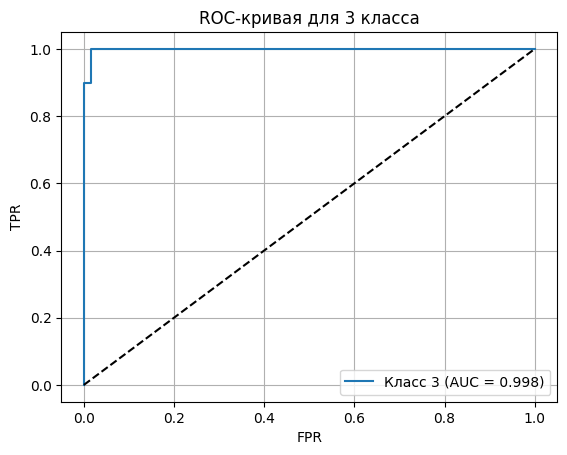

AUC для класса 0: 0.9983
AUC для класса 1: 1.0000
AUC для класса 2: 1.0000
AUC для класса 3: 0.9983

Среднее AUC (macro): 0.9992


In [83]:
y_score_decision_three = decision_three_best.predict_proba(X_test_scaled)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score_svc[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score_decision_three.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
roc_auc["macro"] = np.mean([roc_auc[i] for i in range(n_classes)])

ind_classes = [0, 3]

for ind_class in ind_classes:
    plt.plot(fpr[ind_class], tpr[ind_class], label=f'Класс {ind_class} (AUC = {roc_auc[ind_class]:.3f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.title(f'ROC-кривая для {ind_class} класса')
    plt.legend()
    plt.grid()
    plt.show()

for i in range(n_classes):
    print(f"AUC для класса {i}: {roc_auc[i]:.4f}")
    
mean_auc = np.mean([roc_auc[i] for i in range(n_classes)])
print(f"\nСреднее AUC (macro): {mean_auc:.4f}")

### 5.6. Визуализация полученного дерева решений. Выводы о правилах в узлах. Сопоставление с границами принятия решений.

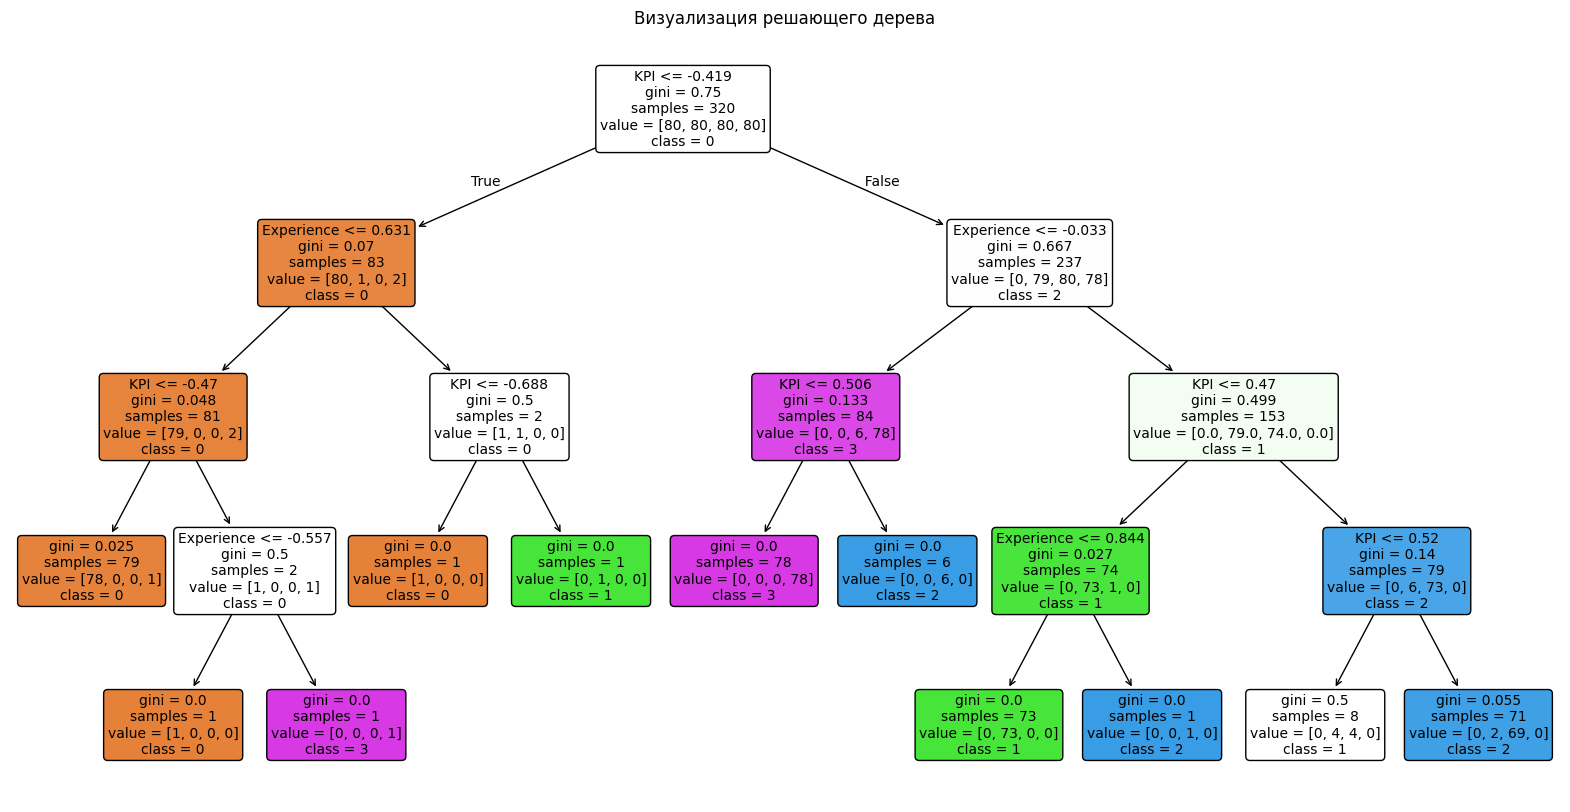

In [62]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    decision_three_best,  
    feature_names=['Experience', 'KPI'],
    class_names=['0', '1', '2', '3'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Визуализация решающего дерева')
plt.show()